In [1]:
import logging
import os
import pickle
import random
import sys
from os.path import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold

sys.path.append("./additional_code")
# from data_preprocessing import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxd/Repositories/ESP/our_codes


In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
anotherdata = pd.read_csv(
    our_data + "geneID_ligandID_docking_gnina_Score_std_uni_true.txt",
    sep="\t",
    header=0,
)

In [4]:
result = anotherdata["complex_name"].str.split(r"_", expand=True)
result.columns = ["enzyme", "substrate", "cc"]
result["substrate_cc"] = result["substrate"] + result["cc"]

anotherdata = pd.concat([anotherdata, result], axis=1)

ourdata = pd.read_pickle(join(CURRENT_DIR, "..", "data", "our_data", "5foldsdata.pkl"))

In [ ]:
print(anotherdata["enzyme"].nunique())
print(anotherdata["substrate"].nunique())
print(ourdata["enzyme"].nunique())
print(ourdata["substrate"].nunique())

299
194
517
237


In [6]:
gninadata = pd.read_pickle(
    join(CURRENT_DIR, "..", "data", "our_data/cache", "gnina.pkl")
)
set(anotherdata["enzyme"].unique().tolist()) - set(gninadata.tolist())

{'5YHJ', 'CYP716S1', 'CYP72A69', 'CYP74C13', 'CYP85A3', 'CYP90C1'}

In [ ]:
result = anotherdata.merge(
    ourdata[["enzyme", "substrate", "scores", "Binding"]],
    on=["enzyme", "substrate"],
    how="left",
)
result = result.dropna()
result.to_pickle(our_data + "combdata.pkl")

In [8]:
result

,p450_name,complex_name,p450_score,affinity,cnn_score,cnn_affi,wei_score,dock_num,if_right,enzyme,substrate,cc,substrate_cc,scores,Binding
2566,CYP72A66v2,CYP72A66v2_ABA_C14,0.132,0.013,0.926,0.388,0.529,5,False,CYP72A66v2,ABA,C14,ABAC14,0.235695,0.0
2567,CYP72A7,CYP72A7_ABA_C14,0.108,0.012,0.918,0.405,0.513,5,False,CYP72A7,ABA,C14,ABAC14,0.120547,0.0
2568,CYP72A62v2,CYP72A62v2_ABA_C14,0.135,0.013,0.836,0.398,0.485,4,False,CYP72A62v2,ABA,C14,ABAC14,0.023919,0.0
2570,CYP707A1,CYP707A1_ABA_C14,0.016,0.012,0.828,0.405,0.422,5,False,CYP707A1,ABA,C14,ABAC14,0.026542,0.0
2571,CYP72A475,CYP72A475_ABA_C14,0.079,0.011,0.828,0.388,0.453,5,False,CYP72A475,ABA,C14,ABAC14,0.116220,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57268,CYP79D16,CYP79D16_PHL_C1,0.556,0.012,0.941,0.303,0.748,3,True,CYP79D16,PHL,C1,PHLC1,0.913152,1.0
57269,CYP79A2,CYP79A2_PHL_C1,0.282,0.012,0.893,0.253,0.588,3,True,CYP79A2,PHL,C1,PHLC1,0.959413,1.0
57270,CYP79D6,CYP79D6_PHL_C1,0.572,0.012,0.891,0.284,0.732,3,True,CYP79D6,PHL,C1,PHLC1,0.961078,1.0
57271,CYP79C1,CYP79C1_PHL_C1,0.501,0.013,0.883,0.254,0.692,3,True,CYP79C1,PHL,C1,PHLC1,0.612343,1.0


In [9]:
print(result["enzyme"].nunique())
print(result["substrate"].nunique())
print(result["complex_name"].nunique())
print(result["substrate_cc"].nunique())

233
146
35214
179


In [10]:
ourdata_N = ourdata.sort_values(by=["substrate", "scores"], ascending=[True, False])
ourdata_N["ranking"] = ourdata_N.groupby("substrate").cumcount() + 1
df1ranking3 = ourdata_N[ourdata_N["Binding"] == 1]["ranking"] / 233
print(df1ranking3.median())

0.11587982832618025


In [11]:
result["wei_score"] = result["wei_score"].round(3)
result["scores"] = result["scores"].round(3)

for i in range(0, 101):
    result["scores" + str(i)] = (
        result["wei_score"] * i / 100 + result["scores"] * (100 - i) / 100
    )
    result["rank" + str(i)] = result.groupby("substrate_cc")["scores" + str(i)].rank(
        method="first", ascending=False
    )

In [ ]:
ratios_list = []

binding_1_values = result[(result["if_right"] == True) & (result["Binding"] == 1)]
for i in range(0, 101):
    binding_1_values["ranking" + str(i)] = binding_1_values["rank" + str(i)] / 233
    ratios_list.append([i, binding_1_values["ranking" + str(i)].median()])
ratios_df = pd.DataFrame(ratios_list, columns=["i", "median"])

In [13]:
binding_1_values.to_csv(our_data + "bin/truescores.csv")

In [14]:
ratios_df

,i,median
0,0,0.060086
1,1,0.060086
2,2,0.055794
3,3,0.055794
4,4,0.055794
...,...,...
96,96,0.042918
97,97,0.051502
98,98,0.060086
99,99,0.068670


In [15]:
ratios_df.sort_values(by="median", ascending=True)

,i,median
77,77,0.025751
78,78,0.025751
83,83,0.025751
82,82,0.025751
79,79,0.025751
...,...,...
98,98,0.060086
0,0,0.060086
1,1,0.060086
99,99,0.068670


In [16]:
ratios_df.sort_values(by="median", ascending=True).to_csv(our_data + "bin/scores.csv")

In [ ]:
rows = [i for i in range(0, 101, 5)]

ratios_df10 = ratios_df.loc[rows]
ratios_df10["i"] = ratios_df10["i"] * 0.01

In [18]:
ratios_df10

,i,median
0,0.00,0.060086
5,0.05,0.055794
10,0.10,0.051502
15,0.15,0.051502
20,0.20,0.047210
25,0.25,0.042918
30,0.30,0.042918
35,0.35,0.038627
40,0.40,0.038627
45,0.45,0.038627


<Figure size 1000x600 with 0 Axes>

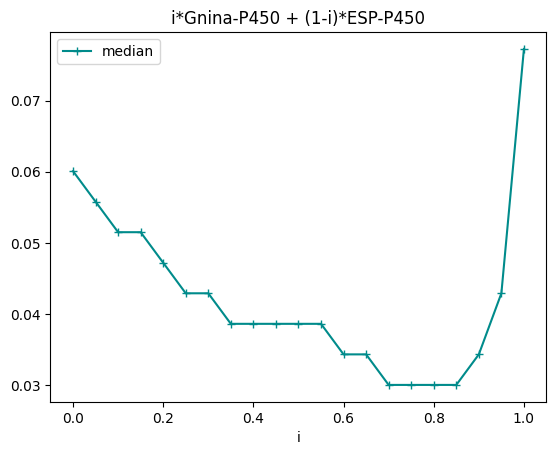

In [ ]:
plt.figure(figsize=(10, 6))
ratios_df10.plot(
    x="i",
    y="median",
    kind="line",
    title="i*Gnina-P450 + (1-i)*ESP-P450",
    marker="+",
    color="#008B8B",
)


plt.show()

In [21]:
result

,p450_name,complex_name,p450_score,affinity,cnn_score,cnn_affi,wei_score,dock_num,if_right,enzyme,...,scores96,rank96,scores97,rank97,scores98,rank98,scores99,rank99,scores100,rank100
2566,CYP72A66v2,CYP72A66v2_ABA_C14,0.132,0.013,0.926,0.388,0.529,5,False,CYP72A66v2,...,0.51728,1.0,0.52021,1.0,0.52314,1.0,0.52607,1.0,0.529,1.0
2567,CYP72A7,CYP72A7_ABA_C14,0.108,0.012,0.918,0.405,0.513,5,False,CYP72A7,...,0.49732,2.0,0.50124,2.0,0.50516,2.0,0.50908,2.0,0.513,2.0
2568,CYP72A62v2,CYP72A62v2_ABA_C14,0.135,0.013,0.836,0.398,0.485,4,False,CYP72A62v2,...,0.46656,4.0,0.47117,4.0,0.47578,4.0,0.48039,4.0,0.485,4.0
2570,CYP707A1,CYP707A1_ABA_C14,0.016,0.012,0.828,0.405,0.422,5,False,CYP707A1,...,0.40620,24.0,0.41015,24.0,0.41410,22.0,0.41805,20.0,0.422,20.0
2571,CYP72A475,CYP72A475_ABA_C14,0.079,0.011,0.828,0.388,0.453,5,False,CYP72A475,...,0.43952,7.0,0.44289,7.0,0.44626,7.0,0.44963,7.0,0.453,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57268,CYP79D16,CYP79D16_PHL_C1,0.556,0.012,0.941,0.303,0.748,3,True,CYP79D16,...,0.75460,1.0,0.75295,1.0,0.75130,1.0,0.74965,1.0,0.748,1.0
57269,CYP79A2,CYP79A2_PHL_C1,0.282,0.012,0.893,0.253,0.588,3,True,CYP79A2,...,0.60284,5.0,0.59913,5.0,0.59542,5.0,0.59171,5.0,0.588,5.0
57270,CYP79D6,CYP79D6_PHL_C1,0.572,0.012,0.891,0.284,0.732,3,True,CYP79D6,...,0.74116,2.0,0.73887,2.0,0.73658,2.0,0.73429,2.0,0.732,2.0
57271,CYP79C1,CYP79C1_PHL_C1,0.501,0.013,0.883,0.254,0.692,3,True,CYP79C1,...,0.68880,3.0,0.68960,3.0,0.69040,3.0,0.69120,3.0,0.692,3.0


In [22]:
result.to_csv(our_data + "cache/allscores.csv")

In [23]:
binding_1_values.to_csv(our_data + "cache/truecores.csv")

In [24]:
binding_1_values.to_pickle(our_data + "true_combine_cores.pkl")

In [25]:
anotherdata

,p450_name,complex_name,p450_score,affinity,cnn_score,cnn_affi,wei_score,dock_num,if_right,enzyme,substrate,cc,substrate_cc
0,3UA1,3UA1_08Y_C22,0.159,0.014,0.814,0.645,0.486,3,True,3UA1,08Y,C22,08YC22
1,CYP707A1,CYP707A1_08Y_C22,0.097,0.043,0.628,0.553,0.362,4,False,CYP707A1,08Y,C22,08YC22
2,CYP76B10,CYP76B10_08Y_C22,0.187,0.100,0.601,0.640,0.394,4,False,CYP76B10,08Y,C22,08YC22
3,CYP72A208,CYP72A208_08Y_C22,0.172,0.072,0.597,0.550,0.384,4,False,CYP72A208,08Y,C22,08YC22
4,CYP725A4,CYP725A4_08Y_C22,0.093,0.011,0.592,0.563,0.342,4,False,CYP725A4,08Y,C22,08YC22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57268,CYP79D16,CYP79D16_PHL_C1,0.556,0.012,0.941,0.303,0.748,3,True,CYP79D16,PHL,C1,PHLC1
57269,CYP79A2,CYP79A2_PHL_C1,0.282,0.012,0.893,0.253,0.588,3,True,CYP79A2,PHL,C1,PHLC1
57270,CYP79D6,CYP79D6_PHL_C1,0.572,0.012,0.891,0.284,0.732,3,True,CYP79D6,PHL,C1,PHLC1
57271,CYP79C1,CYP79C1_PHL_C1,0.501,0.013,0.883,0.254,0.692,3,True,CYP79C1,PHL,C1,PHLC1


In [26]:
anotherdata = anotherdata.sort_values(
    by=["substrate", "wei_score"], ascending=[True, False]
)
anotherdata["ranking"] = anotherdata.groupby("substrate").cumcount() + 1

In [27]:
dfs15 = binding_1_values[["p450_name", "substrate", "cc", "rank80"]]
dfs13 = ourdata[["enzyme", "substrate", "Binding", "scores", "ranking"]]
dfs14 = anotherdata[
    ["p450_name", "substrate", "cc", "substrate_cc", "wei_score", "if_right", "ranking"]
]

dfs13.rename(columns={"enzyme": "P450 enzyme"}, inplace=True)
dfs13.rename(columns={"Binding": "whether catalyzed"}, inplace=True)
dfs13.rename(columns={"scores": "Prediction Scores"}, inplace=True)

dfs14.rename(columns={"p450_name": "P450 enzyme"}, inplace=True)
dfs14.rename(columns={"cc": "Reaction_Sites"}, inplace=True)
dfs14.rename(columns={"if_right": "whether catalyzed"}, inplace=True)
dfs14.rename(columns={"wei_score": "Prediction Scores"}, inplace=True)
dfs14["whether catalyzed"] = dfs14["whether catalyzed"].astype(int)

dfs15.rename(columns={"p450_name": "enzyme"}, inplace=True)
dfs15.rename(columns={"cc": "Reaction_Sites"}, inplace=True)

dfs13.to_csv(our_data + "bin/ourESPdata530.csv")
dfs14.to_csv(our_data + "bin/ourGninadata530.csv")

In [28]:
dfs14

,P450 enzyme,substrate,Reaction_Sites,substrate_cc,Prediction Scores,whether catalyzed,ranking
0,3UA1,08Y,C22,08YC22,0.486,1,1
5,CYP71AY5,08Y,C22,08YC22,0.409,0,2
22,CYP92B14,08Y,C22,08YC22,0.400,0,3
2,CYP76B10,08Y,C22,08YC22,0.394,0,4
9,CYP71D184,08Y,C22,08YC22,0.394,0,5
...,...,...,...,...,...,...,...
55012,2C7X,progesterone,C1,progesteroneC1,0.049,0,137
55007,CYP83A1,progesterone,C1,progesteroneC1,0.033,0,138
55011,CYP736A2,progesterone,C1,progesteroneC1,0.030,0,139
55006,2XBK,progesterone,C1,progesteroneC1,0.026,0,140


In [29]:
dfs14["P450 enzyme"].nunique()

299

In [30]:
dfs14["substrate_cc"].nunique()

229

In [ ]:
result_1 = pd.merge(
    dfs13, dfs14, on=["P450 enzyme", "substrate", "whether catalyzed"], how="inner"
)
result_1.rename(columns={"ranking_y": "rank_Gnina-P450"}, inplace=True)
result_1.rename(columns={"ranking_x": "rank_ESP-P450"}, inplace=True)

result_2 = pd.merge(
    result_1,
    dfs15,
    left_on=["P450 enzyme", "substrate"],
    right_on=["enzyme", "substrate"],
    how="inner",
)

In [32]:
dfs15 = result_2[
    [
        "enzyme",
        "substrate",
        "Reaction_Sites_y",
        "rank80",
        "rank_ESP-P450",
        "rank_Gnina-P450",
    ]
]
dfs15.rename(columns={"Reaction_Sites_y": "Reaction_Sites"}, inplace=True)

In [33]:
dfs15

,enzyme,substrate,Reaction_Sites,rank80,rank_ESP-P450,rank_Gnina-P450
0,CYP706A3,ABA,C14,37.0,211,34
1,CYP720B1,ABI,C17,2.0,7,6
2,CYP707A1,ABS,C5,1.0,4,5
3,CYP720B4,ABT,C12,65.0,328,25
4,CYP97A3,ACA,C34,2.0,3,41
...,...,...,...,...,...,...
228,CYP714E19,UAC,C26,1.0,44,1
229,CYP71D4,VAE,C10,1.0,1,4
230,CYP71D55,VAE,C10,2.0,2,5
231,CYP706M1,VAE,C10,176.0,208,232


In [34]:
dfs15.to_csv(our_data + "bin/ourcomb530.csv")

In [35]:
anotherdata[
    (anotherdata["p450_name"] == "CYP98A6") & (anotherdata["substrate"] == "CHP")
]

,p450_name,complex_name,p450_score,affinity,cnn_score,cnn_affi,wei_score,dock_num,if_right,enzyme,substrate,cc,substrate_cc,ranking
10825,CYP98A6,CYP98A6_CHP_C17,0.077,0.010,0.725,0.303,0.401,1,True,CYP98A6,CHP,C17,CHPC17,116
11241,CYP98A6,CYP98A6_CHP_C9,0.082,0.012,0.458,0.292,0.270,2,False,CYP98A6,CHP,C9,CHPC9,373


In [36]:
dfs15["substrate"].nunique()

144